1. NAV trend analysis: Plot daily NAV for
all 40 schemes 2022–2026. Highlight
COVID recovery, 2023 rally, 2024
corrections.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

nav_his = pd.read_csv("../data/processed/nav_history.csv")
# print(nav_his.columns)
# print(nav_his.info())
nav_his['date'] = pd.to_datetime(nav_his['date'])

# filter date
nav_his = nav_his[
    (nav_his['date'] >= "2022-01-01") &
    (nav_his['date'] <= "2026-12-31")
]

# sort
nav_his = nav_his.sort_values(['amfi_code', 'date'])


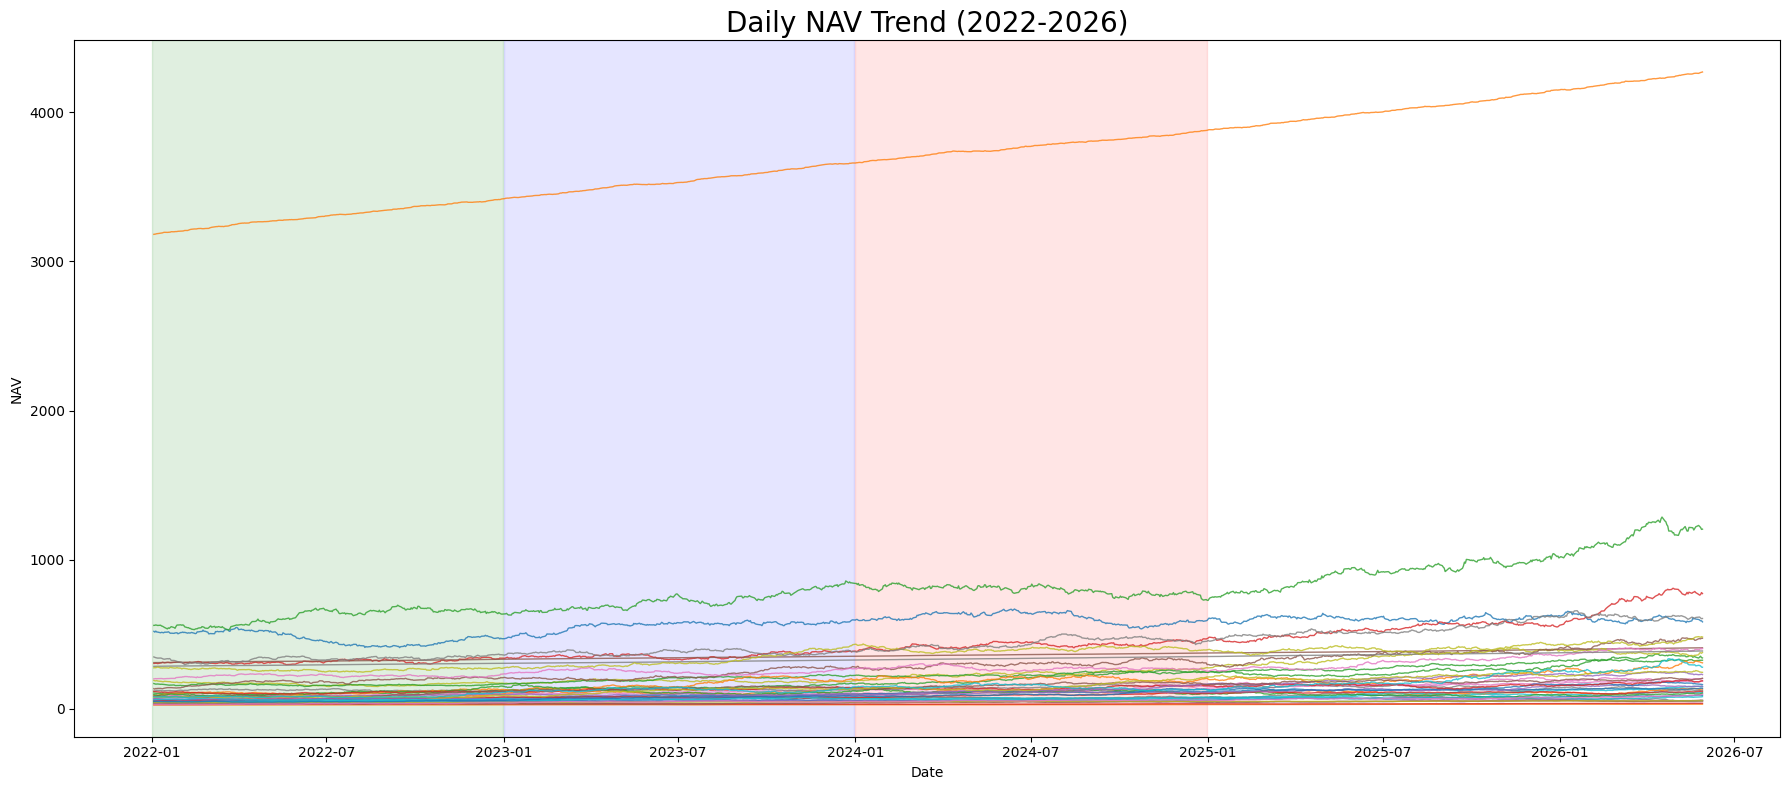

In [ ]:
plt.figure(figsize=(18,8))
for scheme in nav_his['amfi_code'].unique():
    scheme_df = nav_his[nav_his['amfi_code'] == scheme]
    plt.plot(
        scheme_df['date'],
        scheme_df['nav'],
        label= scheme,
        linewidth = 1,
        alpha = 0.8
    )

# highlight
plt.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-12-31"),
    color="green",
    alpha=0.12,
    label="COVID Recovery"
)

plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    color="blue",
    alpha=0.10,
    label="COVID Rally"
)

plt.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
    color="red",
    alpha=0.10,
    label="2024 Correction"
)

plt.title("Daily NAV Trend (2022-2026)", fontsize=20)
plt.xlabel("Date")
plt.ylabel("NAV")
# plt.legend()
plt.tight_layout()
plt.savefig("../reports/nav_trend_matplotlib.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
fig = px.line(
    nav_his,
    x='date',
    y='nav',
    color='amfi_code',
    title="Daily NAV Trend (2022-2026)",
    labels={
        "date" : "Date",
        "nav" : "NAV",
        "amfi_code" : "Scheme"
    }
)

fig.add_vrect(
    x0="2022-01-01",
    x1="2022-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="COVID Recovery",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="blue",
    opacity=0.10,
    line_width=0,
    annotation_text="2023 Relly",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.write_html("../reports/nav_trend_plotly.html")
fig.show()

2. AUM growth bar chart: Grouped bar
chart — AUM by fund house for each
year 2022–2025. Highlight SBI's
dominance at Rs.12.5L Cr.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv("../data/processed/aum_by_fund_house.csv")
# print(aum.columns)
# print(aum.info())

aum['date'] = pd.to_datetime(aum['date'])
# filter
aum = aum[(aum['date'] >= "2022-01-01") & (aum['date'] <= "2025-12-31")]
aum = aum.sort_values(["date", "aum_crore"], ascending=[True, False])
# print(aum.head(3))

yearly_aum = (
    aum.assign(year=aum['date'].dt.year)
    .groupby(['year', 'fund_house'], as_index=False)
    .agg({'aum_lakh_crore':"sum"})
)
# print(yearly_aum.head())

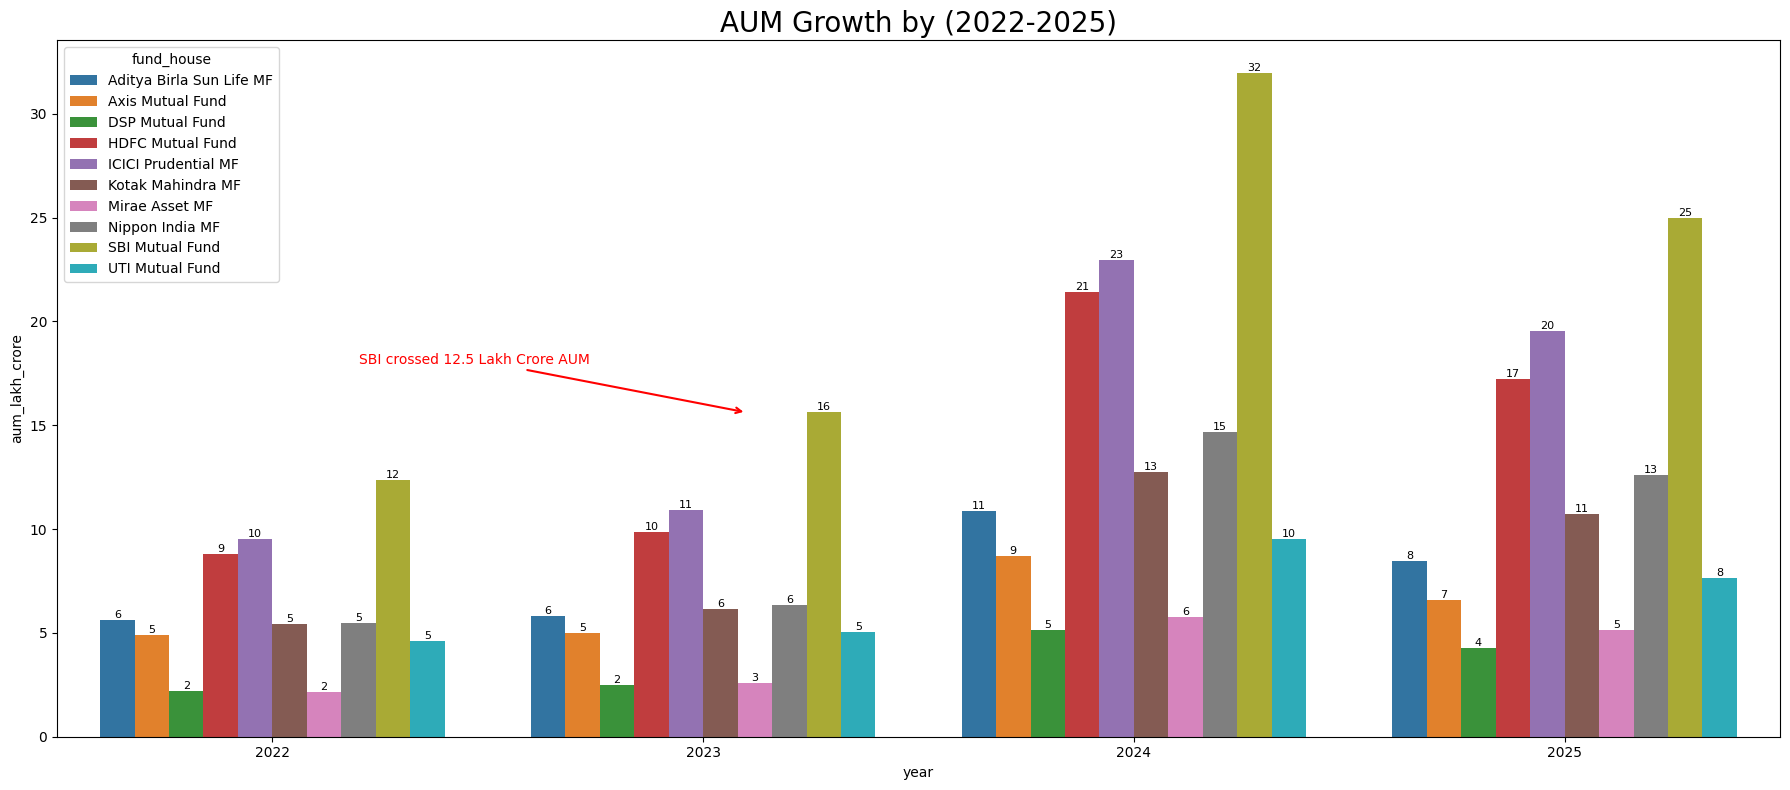

In [ ]:
plt.figure(figsize=(18,8))
ax = sns.barplot(
    data=yearly_aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=8
    )

sbi = yearly_aum[(yearly_aum['fund_house'] == "SBI Mutual Fund") & (yearly_aum['aum_lakh_crore'] > 12.5)].sort_values('year').iloc[0]
year_list = sorted(list(yearly_aum['year'].unique()))
# print(sbi)
# print(year_list)
x_pos = year_list.index(sbi['year'])
y_pos = sbi['aum_lakh_crore']
plt.annotate(
    "SBI crossed 12.5 Lakh Crore AUM",
    xy=(x_pos + 0.1, y_pos),
    xytext=(x_pos - 0.8, y_pos + (y_pos * 0.15)),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.5
    ),
    color="red"
)
plt.title("AUM Growth by (2022-2025)", fontsize=20)
plt.tight_layout()
plt.savefig("../reports/aum_growth_by_amc.png", dpi = 300, bbox_inches="tight")
plt.show()

3. SIP inflow time-series: Monthly SIP
inflow Jan 2022 to Dec 2025. Mark
the Rs.31,002 Cr milestone (Dec
2025).

In [2]:
import pandas as pd
import plotly.express as px

sip_inflow = pd.read_csv("../data/processed/monthly_sip_inflows.csv")
sip_inflow['month'] = pd.to_datetime(sip_inflow['month'], format="%Y-%m")
# print(sip_inflow.columns)
# print(sip_inflow.info())

sip_inflow = sip_inflow[
    (sip_inflow['month'] >= "2022-01-01") &
    (sip_inflow['month'] <= "2025-12-31")
]
sip_inflow = sip_inflow.sort_values('month')
# print(sip_inflow.head(2))

In [ ]:
fig = px.line(
    sip_inflow,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title="Monthly SIP inflow (jan 2022 - dec 2025)",
    labels={
        "month" : "Month",
        "sip_inflow_crore" : "SIP Inflow Crore"
    }
)

fig.add_scatter(
    x=["2025-12-01"],
    y=[31002],
    mode="markers+text",
    marker=dict(
        size=14,
        color="red",
        symbol="star"
    ),
    text=["31,002 Cr"],
    textposition="top center",
    name="Milestone"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="Highest SIP inflow 31002 Cr.",
    showarrow=True,
    arrowhead=2,
    ax=-120,
    ay=-50
)

fig.update_layout(
    hovermode="x unified",
    template="plotly_white"
)
fig.write_html("../reports/sip_inflow_timeseries.html")
# fig.write_image("../reports/sip_inflow_timeseries.png", engine="kaleido")
fig.show()

C:\Users\Bubai Das\AppData\Local\Temp\ipykernel_17180\3174353616.py:42: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image("../reports/sip_inflow_timeseries.png", engine="kaleido")


4. Category-wise inflow heatmap:
Months on X-axis, categories on
Y-axis, net inflow as colour intensity.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cate_inflow = pd.read_csv("../data/processed/category_inflows.csv")
cate_inflow['month'] = pd.to_datetime(cate_inflow['month'], format="%Y-%m")
cate_inflow = cate_inflow.sort_values("month")

# print(cate_inflow.columns)
# print(cate_inflow.info())
# print(cate_inflow)

In [ ]:
heatmap_data = cate_inflow.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)
heatmap_data.columns = heatmap_data.columns.strftime('%b-%Y')
# print(heatmap_data.head())

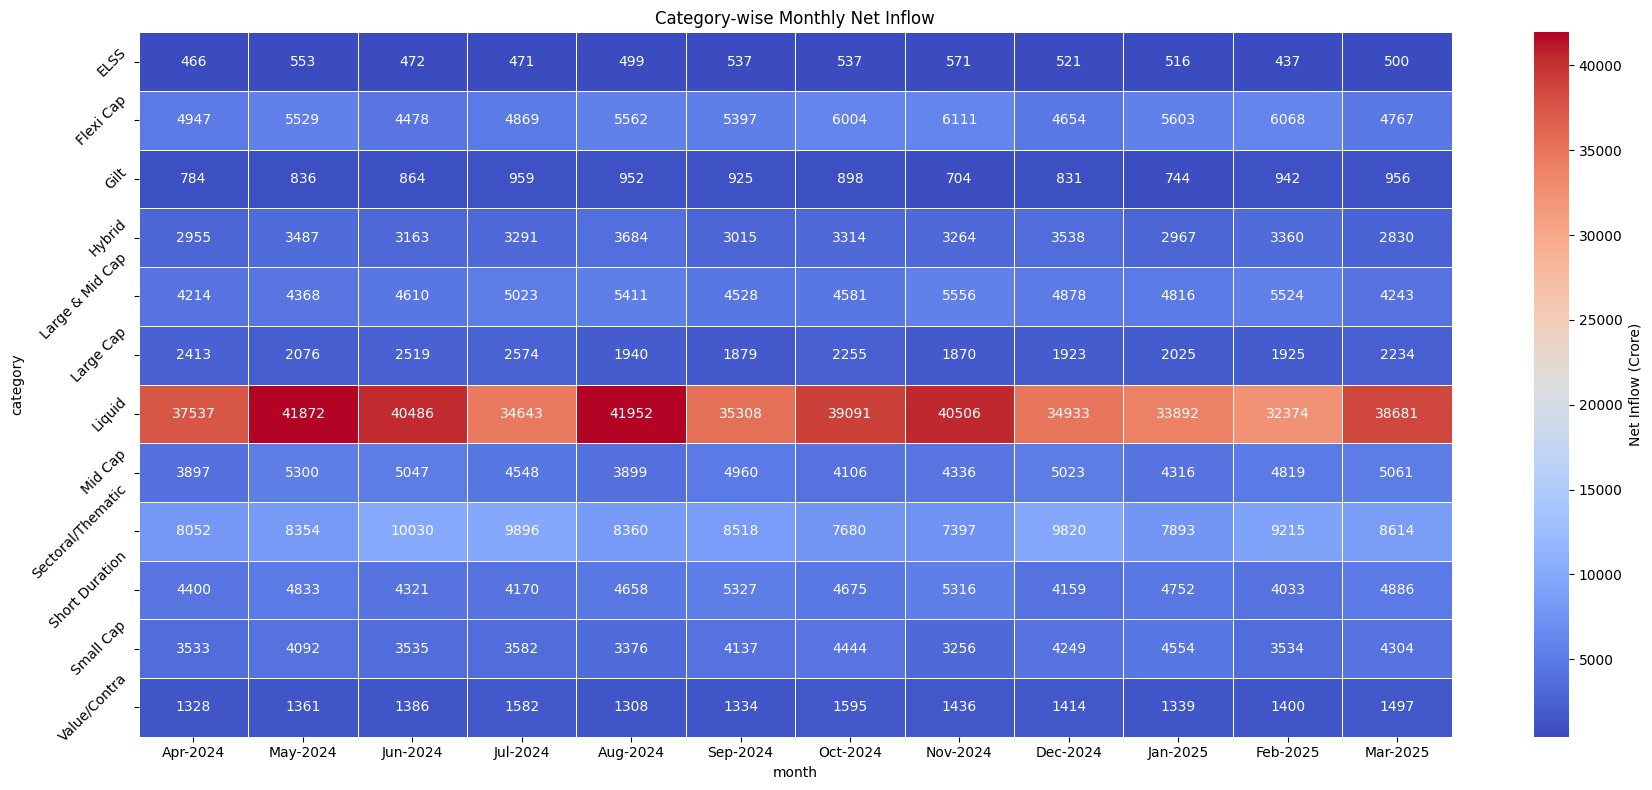

In [ ]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (Crore)"}
)
plt.title("Category-wise Monthly Net Inflow")
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/category_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

5. Investor demographics: Age group
distribution pie chart. SIP amount box
plot by age group.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/investor_transactions.csv")
# print(df.columns)
sip_df = df[df['transaction_type'] == "SIP"].groupby("investor_id")['amount_inr'].sum()
# print(sip_df.head())
inve_demog = df[
    ["investor_id", 'age_group', 'gender', 'state', 'city', 'city_tier']
    ].drop_duplicates()
inve_demog['SIP_amount'] = inve_demog['investor_id'].map(sip_df).fillna(0)

inve_demog = inve_demog.sort_values('age_group')
# print(inve_demog.columns)
# print(inve_demog.info())
# print(inve_demog.head())

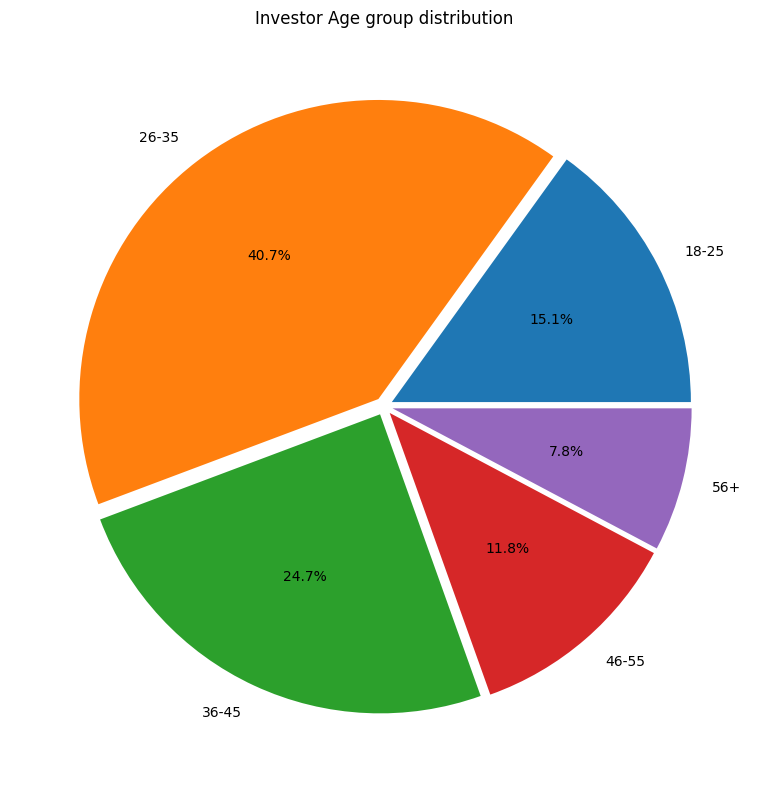

In [ ]:
age_distribution = (
    inve_demog['age_group']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(18,8))

plt.pie(
    age_distribution,
    labels=age_distribution.index,
    autopct="%1.1f%%",
    explode=[0.03]*len(age_distribution)
)

plt.title("Investor Age group distribution")
plt.tight_layout()
plt.savefig("../reports/investor_age_distribution.png", dpi=300, bbox_inches = "tight")
plt.show()

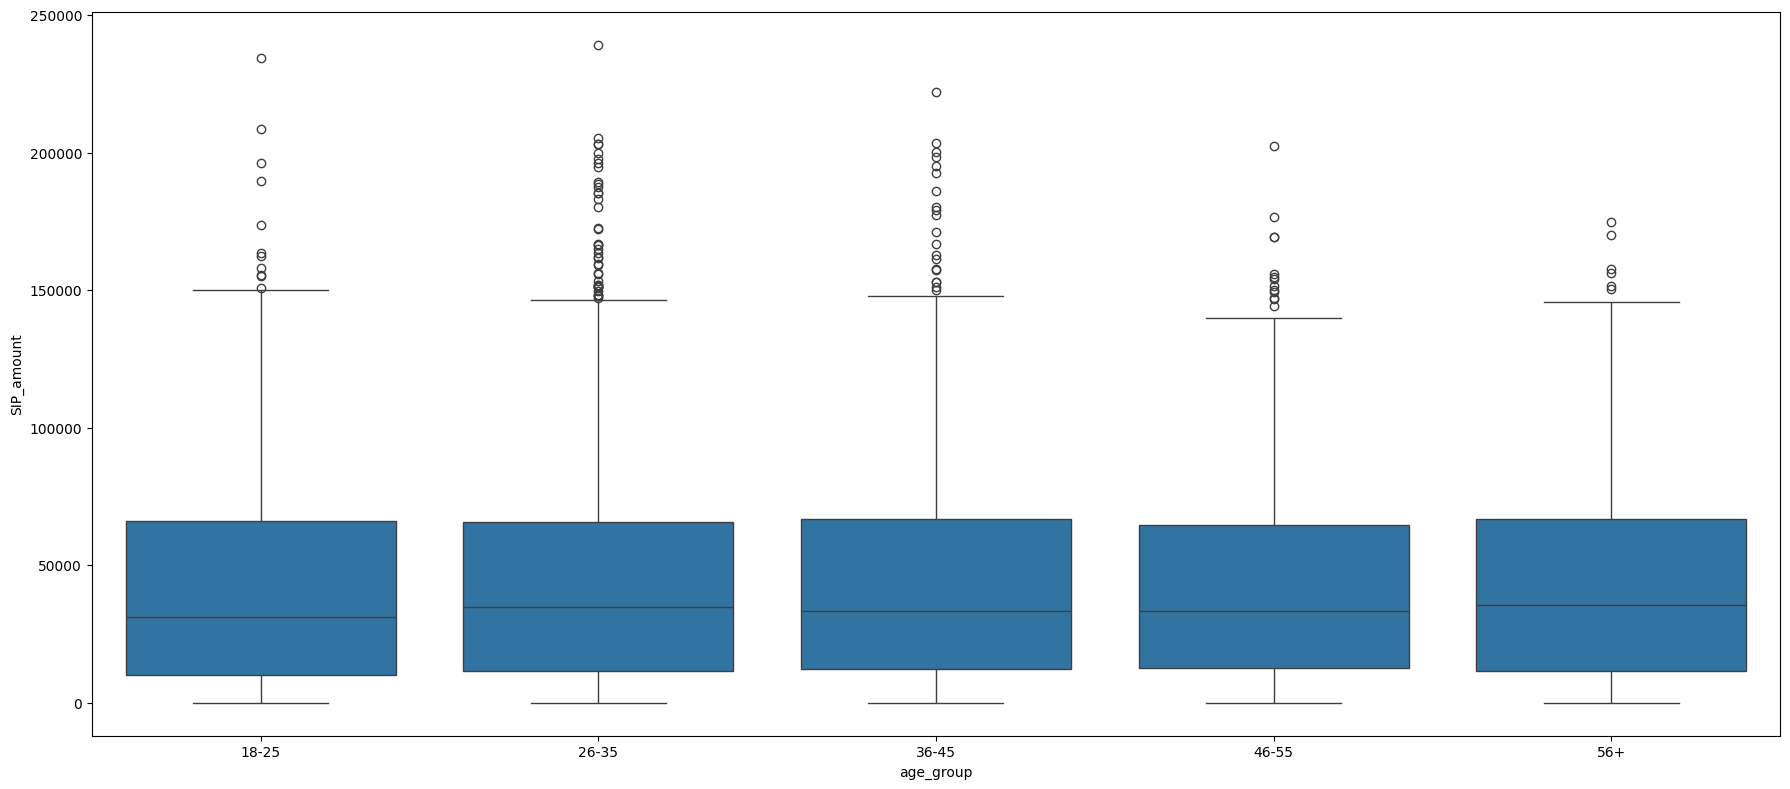

In [ ]:
plt.figure(figsize=(18,8))

sns.boxplot(
    data=inve_demog,
    x="age_group",
    y="SIP_amount"
)

plt.tight_layout()
plt.savefig("../reports/sip_box_plot.png", dpi=300, bbox_inches = "tight")
plt.show()


6. Geographic distribution: Horizontal
bar chart — SIP amount by state. T30
vs B30 pie chart.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/investor_transactions.csv")
# print(df.columns)
sip_df = df[df['transaction_type'] == "SIP"].groupby("investor_id")['amount_inr'].sum()
# print(sip_df.head())
inve_demog = df[
    ["investor_id", 'age_group', 'gender', 'state', 'city', 'city_tier']
    ].drop_duplicates()
inve_demog['SIP_amount'] = inve_demog['investor_id'].map(sip_df).fillna(0)

inve_demog = inve_demog.sort_values('age_group')
# print(inve_demog.columns)
# print(inve_demog.info())
# print(inve_demog.head())

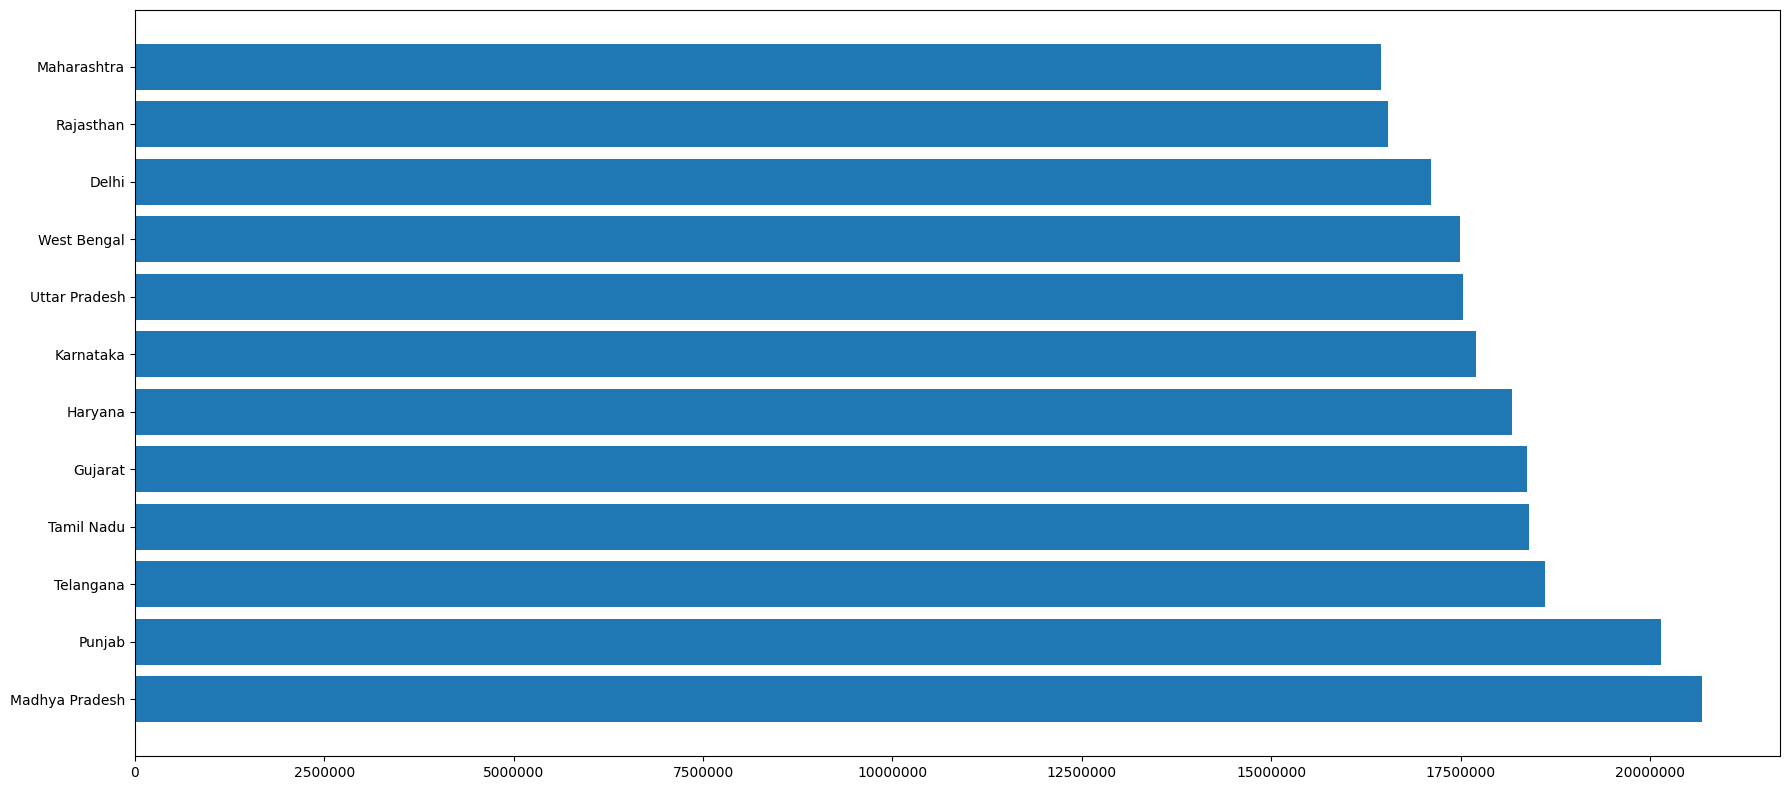

In [ ]:
state_sip = (
    inve_demog.groupby('state')['SIP_amount']
    .sum()
    .sort_values(ascending=False)
)
# print(state_sip.head())
plt.figure(figsize=(18,8))
plt.barh(state_sip.index, state_sip.values)
plt.ticklabel_format(style="plain", axis='x')
plt.tight_layout()
plt.savefig("../reports/sip_by_state.png", dpi=300, bbox_inches = "tight")
plt.show()

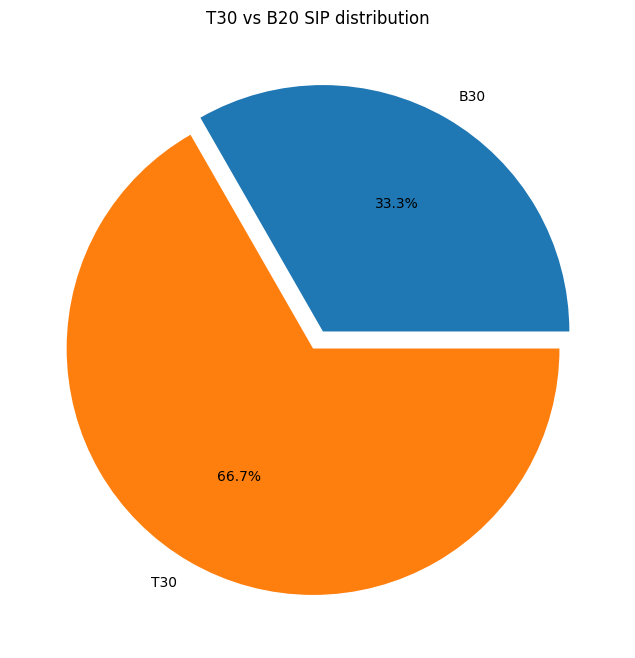

In [ ]:
city_distribution = (
    inve_demog.groupby("city_tier")['SIP_amount']
    .sum()
)
# print(city_distribution.head())
plt.figure(figsize=(18,8))

plt.pie(
    city_distribution,
    labels=city_distribution.index,
    autopct="%1.1f%%",
    explode=[0.04,0.04]
)
plt.title("T30 vs B20 SIP distribution")
plt.savefig("../reports/t30_b20_sip_distribution.png", dpi=300, bbox_inches = "tight")
plt.show()

7. Folio count growth: Line chart Jan
2022 to Dec 2025 showing growth
from 13.26 to 26.12 crore.

In [5]:
import pandas as pd
import plotly.express as px

industry_folio = pd.read_csv("../data/processed/industry_folio_count.csv")
# print(industry_folio.columns)
industry_folio['month'] = pd.to_datetime(industry_folio['month'], format='%Y-%m')
industry_folio = industry_folio[
    (industry_folio["month"] >= "2022-01-01") &
    (industry_folio["month"] <= "2025-12-31")
]
industry_folio = industry_folio.sort_values('month')
# print(industry_folio.head())

In [7]:
fig = px.line(
    industry_folio,
    x='month',
    y='total_folios_crore',
    markers=True,
    title="Mutual Fund folio count growth 2022 - 2025",
    labels={
        'month' : "Month",
        'total_folios_crore' : "Folio count (Crore)"
    }
)

fig.add_scatter(
    x=['2022-01-01'],
    y=[13.26],
    mode="markers+text",
    marker=dict(
        color="green",
        symbol="circle"
    ),
    text=["13.26 Cr."],
    textposition="bottom right",
    name="Jan 2022"
)

fig.add_scatter(
    x=['2025-12-01'],
    y=[26.12],
    mode="markers+text",
    marker=dict(
        color="red",
        symbol="star"
    ),
    text=["26.12 Cr."],
    textposition="top center",
    name="Dec 2025"
)

fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="Folio count doubled 26.12 Crore.",
    showarrow=True,
    arrowhead=5,
    ax=-120,
    ay=-25
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig.write_html("../reports/folio_count_growth.html")
fig.write_image("../reports/folio_count_growth.png", engine="kaleido")
fig.show()

C:\Users\Bubai Das\AppData\Local\Temp\ipykernel_17180\1813511569.py:55: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image("../reports/folio_count_growth.png", engine="kaleido")


8. Correlation matrix: Compute pairwise
correlation of NAV returns across 10
selected funds.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/nav_history.csv")

df['date'] = pd.to_datetime(df['date'])
# print(df.columns)
# print(df.info())
# print(df.head())

In [ ]:
df = df[df['amfi_code'].isin([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886, 102887, 118632])]

In [ ]:
pivot_df = df.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)
# print(pivot_df.head())
returns = pivot_df.pct_change()
returns = returns.dropna()
# print(returns.head())
corr_matrix = returns.corr()
# print(corr_matrix)

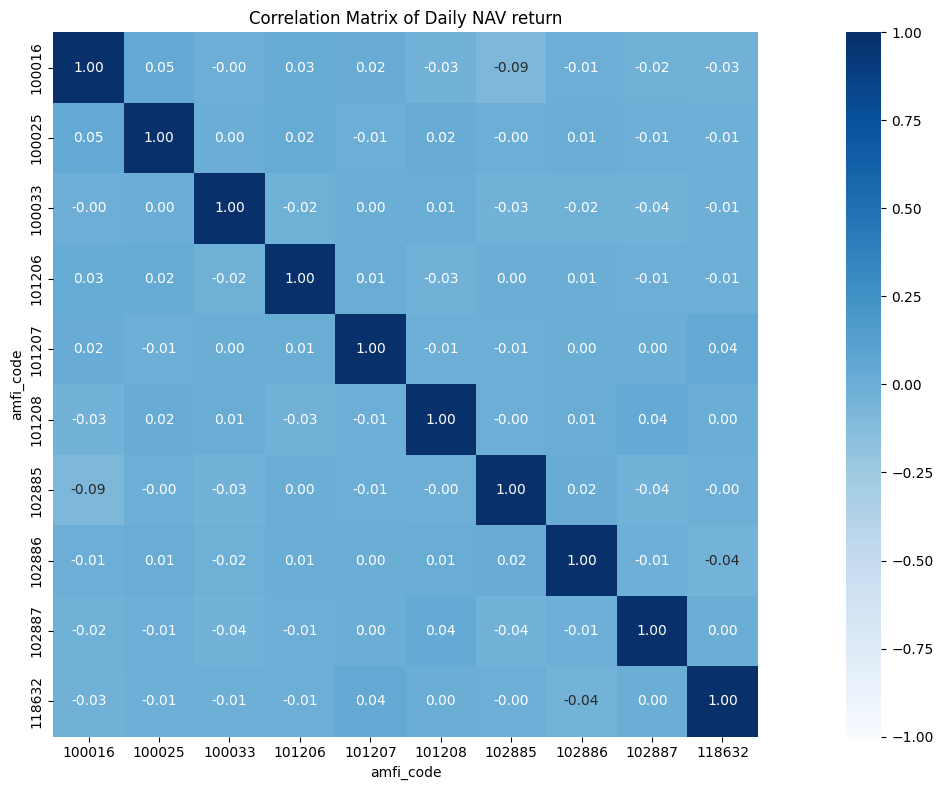

In [ ]:
plt.figure(figsize=(18,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    square=True,
    vmax=1,
    vmin=-1
)

plt.title("Correlation Matrix of Daily NAV return")
plt.tight_layout()
plt.savefig("../reports/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

9. Top holdings sector distribution:
Pie/donut chart of sector weights
across all equity fund portfolios.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

portfolio = pd.read_csv('../data/processed/portfolio_holdings.csv')

# print(portfolio.columns)
# print(portfolio.info())
# print(portfolio.head(2))

sector_weight = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)
# print(sector_weight)

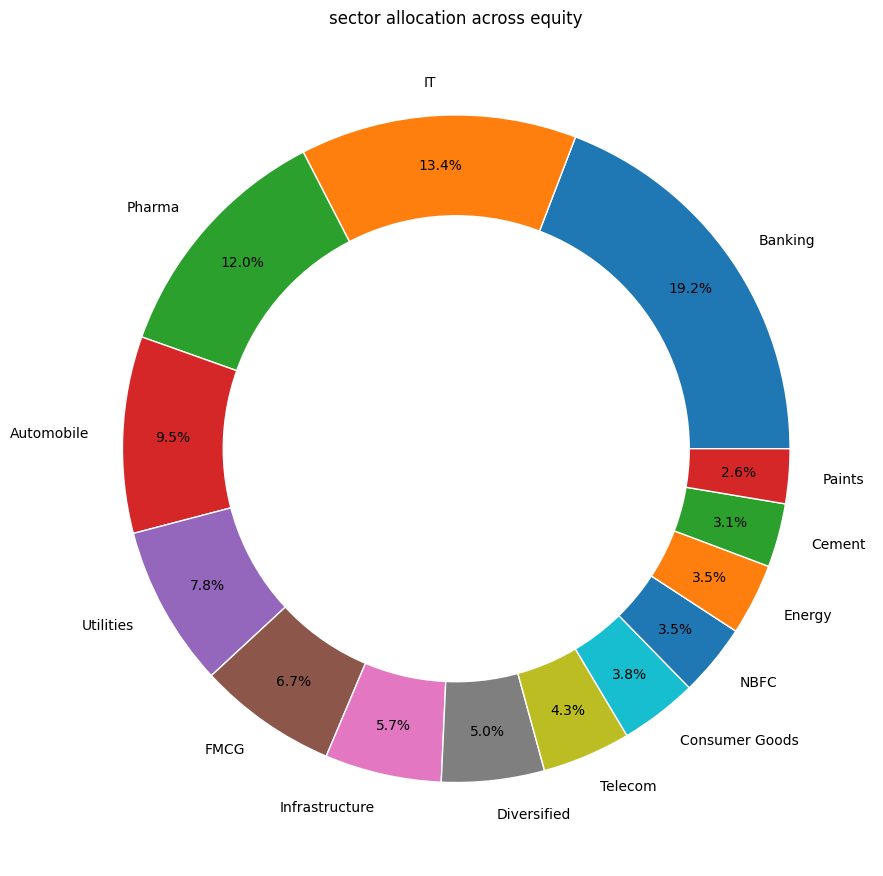

In [ ]:
fig, ax = plt.subplots(figsize=(9,9))
wedges, texts, autotext = ax.pie(
    sector_weight,
    labels=sector_weight.index,
    autopct="%1.1f%%",
    pctdistance=0.85,
    wedgeprops=dict(edgecolor="white")
)

center_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig.gca().add_artist(center_circle)
plt.title("sector allocation across equity")
plt.tight_layout()
plt.savefig("../reports/sector_allocation_donut.png", dpi = 300, bbox_inches="tight")
plt.show()
